# Telco Customer Churn — Exploratory Data Analysis

**Goal:** understand *why* customers churn — which factors are most associated with a customer leaving — using the Telco Customer Churn dataset (7,043 customers, 21 columns).

**Structure of this notebook:**
1. Load & inspect the data
2. Clean the data (fix types, handle missing values)
3. Target variable (`Churn`) overview
4. Churn vs. demographics
5. Churn vs. contract / billing
6. Churn vs. subscribed services
7. Churn vs. numeric features (tenure, charges)
8. Correlation view
9. Summary dashboard of the strongest churn drivers
10. Key insights & takeaways

Each analysis section ends with a short **Insight** note summarizing what the chart/table tells us.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global plotting style for a clean, consistent "dashboard" look
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

CHURN_COLORS = {"No": "#4C72B0", "Yes": "#DD8452"}  # consistent color coding for Churn across all plots

## 1. Load & Inspect the Data

In [2]:
df = pd.read_csv(r"..\data\Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Basic statistics for numeric columns
df.describe(include="number")

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Data Cleaning

Checks performed:
- Duplicate `customerID`s
- Missing values per column
- Correct data types (`TotalCharges` is loaded as text, not numeric)
- Sanity of categorical value labels

In [5]:
# Duplicate customer IDs
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())

# Missing values (as pandas sees them at load time)
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "None detected by pandas at load time.")

Duplicate customerIDs: 0

Missing values per column:
None detected by pandas at load time.


In [6]:
# TotalCharges is stored as an object (string) column — let's see why
print(df["TotalCharges"].dtype)

# Convert to numeric; any value that can't be converted becomes NaN
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
bad_rows = df[total_charges_numeric.isna()]
print(f"\nRows where TotalCharges could not be converted to a number: {len(bad_rows)}")
bad_rows[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

str

Rows where TotalCharges could not be converted to a number: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Finding:** 11 rows have a blank string for `TotalCharges`. All 11 have `tenure == 0`, i.e. brand-new customers who have not been billed a full cycle yet — this isn't random data corruption, it's an expected edge case.

**Fix:** convert `TotalCharges` to numeric and set these `tenure == 0` rows to `0` (no charges accrued yet), rather than dropping the rows or imputing a mean that doesn't reflect reality.

In [7]:
# Apply the fix
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Clean up categorical text some services use ("No internet service" / "No phone service")
# We keep these as their own category since they carry real information (no internet -> can't have online security etc.)
# but we also make a binary churn flag for numeric analysis
df["Churn_Flag"] = (df["Churn"] == "Yes").astype(int)

# SeniorCitizen is numeric (0/1) but is really categorical — map to Yes/No for readable plots
df["SeniorCitizen_Label"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

print("TotalCharges dtype after fix:", df["TotalCharges"].dtype)
print("Remaining missing values:", df.isnull().sum().sum())
df[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn", "Churn_Flag"]].head()

TotalCharges dtype after fix: float64
Remaining missing values: 0


,customerID,tenure,MonthlyCharges,TotalCharges,Churn,Churn_Flag
0,7590-VHVEG,1,29.85,29.85,No,0
1,5575-GNVDE,34,56.95,1889.50,No,0
2,3668-QPYBK,2,53.85,108.15,Yes,1
3,7795-CFOCW,45,42.30,1840.75,No,0
4,9237-HQITU,2,70.70,151.65,Yes,1


## 3. Target Variable: `Churn` Overview

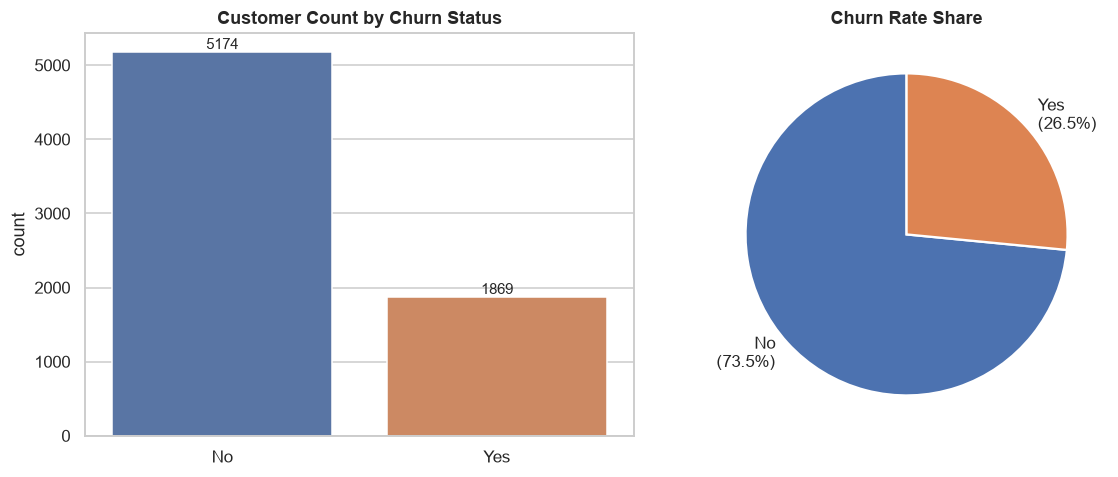

Overall churn rate: 26.54%


In [8]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.countplot(data=df, x="Churn", order=["No", "Yes"], palette=CHURN_COLORS, ax=axes[0])
axes[0].set_title("Customer Count by Churn Status")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                      ha="center", va="bottom", fontsize=10)

axes[1].pie(churn_pct, labels=[f"{i}\n({v:.1f}%)" for i, v in churn_pct.items()],
            colors=[CHURN_COLORS[i] for i in churn_pct.index], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Churn Rate Share")

plt.tight_layout()
plt.show()

print(f"Overall churn rate: {churn_pct['Yes']:.2f}%")

**Insight:** About **26.5%** of customers have churned. This is a meaningfully imbalanced target (roughly 1 churner for every 2.8 retained customers) — worth keeping in mind if this dataset is later used for predictive modeling (e.g. need for class weighting, stratified sampling, or resampling).

## 4. Churn vs. Demographics

Looking at `gender`, `SeniorCitizen`, `Partner`, `Dependents`.

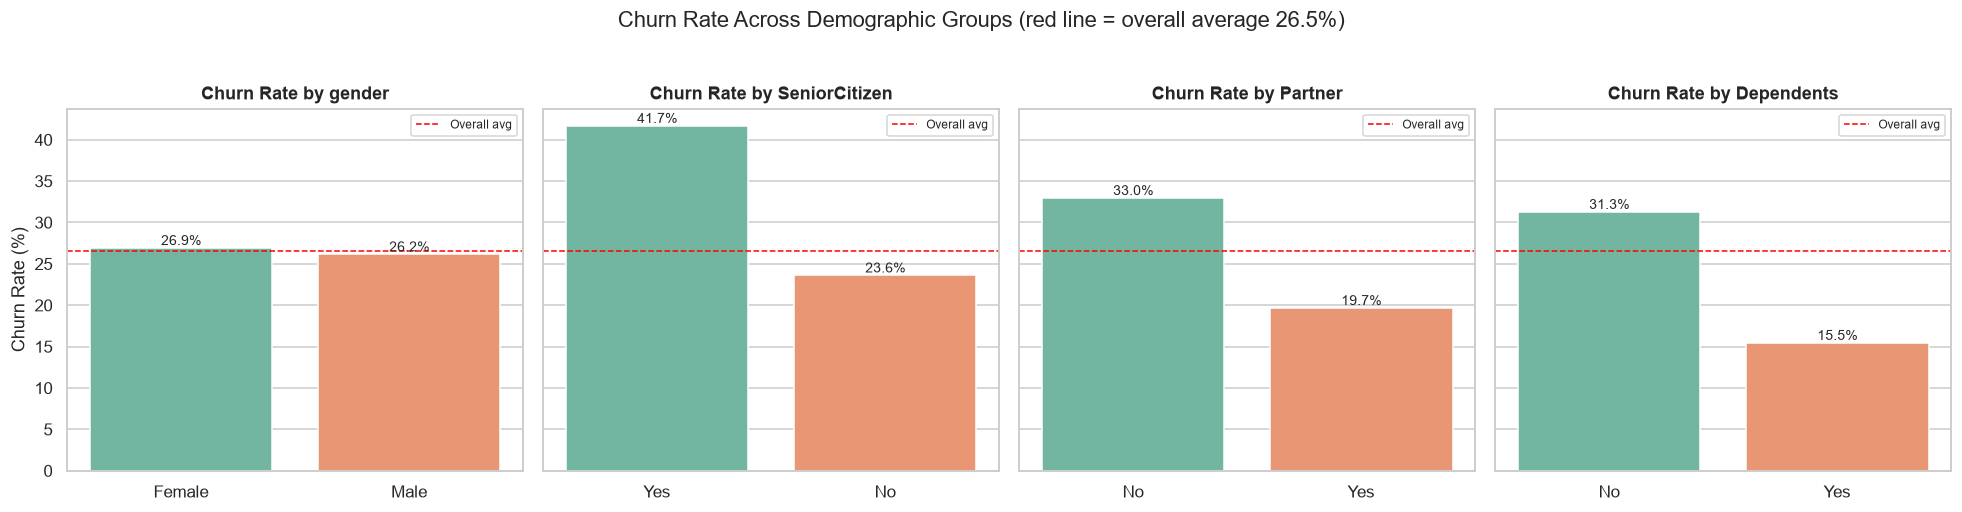

In [9]:
demo_cols = ["gender", "SeniorCitizen_Label", "Partner", "Dependents"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for ax, col in zip(axes, demo_cols):
    rate = df.groupby(col)["Churn_Flag"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette="Set2")
    ax.set_title(f"Churn Rate by {col.replace('_Label','')}")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel("")
    ax.axhline(df["Churn_Flag"].mean() * 100, color="red", linestyle="--", linewidth=1, label="Overall avg")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle("Churn Rate Across Demographic Groups (red line = overall average 26.5%)", y=1.03)
plt.tight_layout()
plt.show()

**Insight:**
- **Gender has almost no effect** on churn — male and female customers churn at nearly identical rates. Not a useful predictor.
- **Senior citizens churn far more** (~41.7%) than non-seniors (~23.6%) — nearly double the rate.
- **Customers without a partner** churn more (~33.0%) than those with one (~19.7%).
- **Customers without dependents** churn more (~31.3%) than those with dependents (~15.5%).

Overall, customers who are **single / living alone** (no partner, no dependents) and **older** are more likely to leave — suggesting less "lock-in" to the household/service and possibly different price sensitivity or service needs.

## 5. Churn vs. Contract & Billing

Looking at `Contract`, `PaperlessBilling`, and `PaymentMethod` — these describe the *commercial relationship* with the customer.

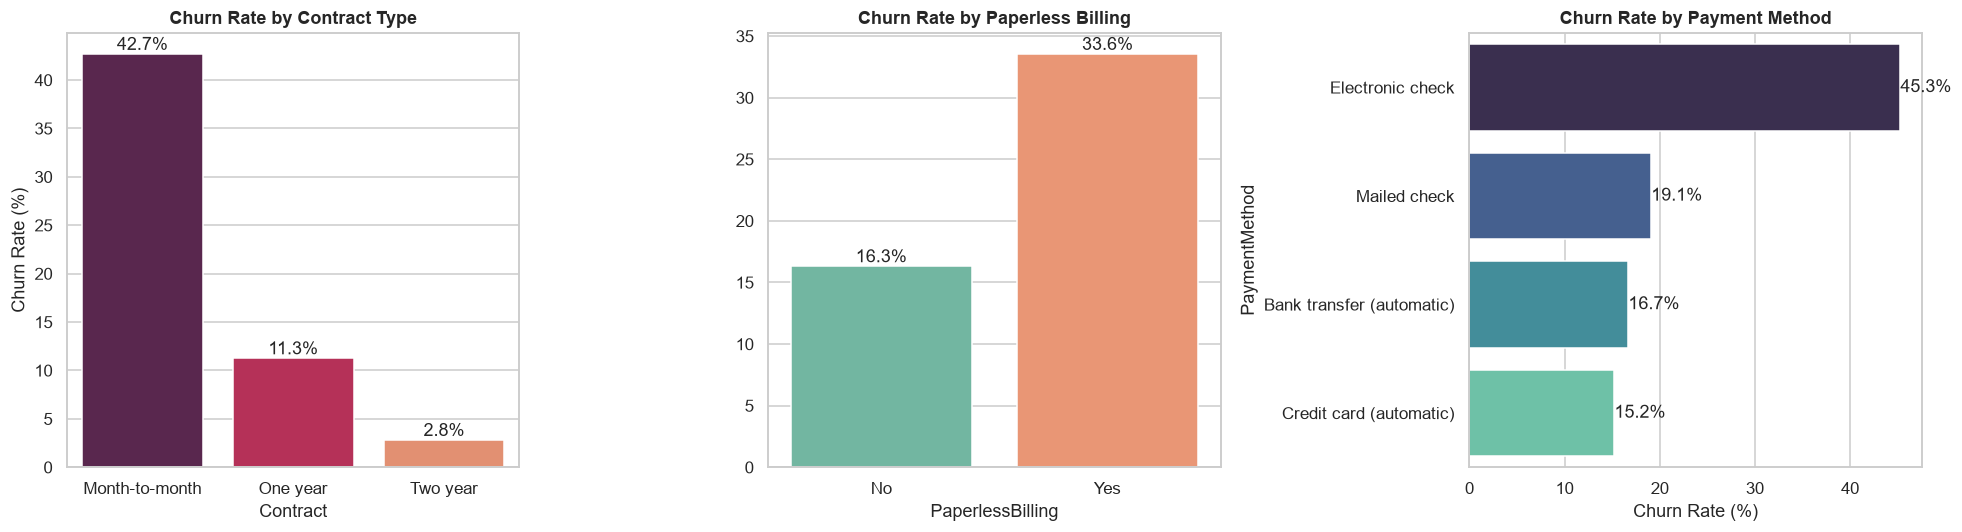

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Contract
order = ["Month-to-month", "One year", "Two year"]
rate = (df.groupby("Contract")["Churn_Flag"].mean() * 100).reindex(order)
sns.barplot(x=rate.index, y=rate.values, ax=axes[0], palette="rocket")
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylabel("Churn Rate (%)")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")

# Paperless Billing
rate = df.groupby("PaperlessBilling")["Churn_Flag"].mean() * 100
sns.barplot(x=rate.index, y=rate.values, ax=axes[1], palette="Set2")
axes[1].set_title("Churn Rate by Paperless Billing")
axes[1].set_ylabel("")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")

# Payment Method
rate = (df.groupby("PaymentMethod")["Churn_Flag"].mean() * 100).sort_values(ascending=False)
sns.barplot(x=rate.values, y=rate.index, ax=axes[2], palette="mako")
axes[2].set_title("Churn Rate by Payment Method")
axes[2].set_xlabel("Churn Rate (%)")
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_width():.1f}%", (p.get_width(), p.get_y()+p.get_height()/2), ha="left", va="center")

plt.tight_layout()
plt.show()

**Insight — this is where the biggest signal in the whole dataset lives:**
- **Contract type is the single strongest driver of churn found in this analysis.** Month-to-month customers churn at **42.7%**, vs **11.3%** for one-year contracts and only **2.8%** for two-year contracts. Longer commitment overwhelmingly correlates with retention.
- **Paperless billing customers churn more** (33.6%) than non-paperless (16.3%) — this likely correlates with the type of customer who chooses month-to-month/electronic-check billing rather than being causal on its own.
- **Electronic check payers churn the most** (45.3%), far above mailed check (19.1%), bank transfer (16.7%), and credit card (15.2%). This may reflect a demographic that is less "locked in" via autopay, or friction/dissatisfaction with the payment experience.

## 6. Churn vs. Subscribed Services

Looking at `InternetService` and the add-on services (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`).

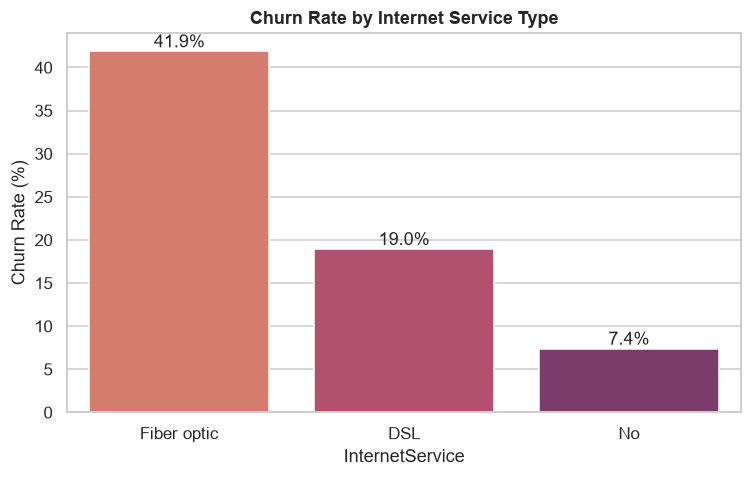

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
rate = (df.groupby("InternetService")["Churn_Flag"].mean() * 100).sort_values(ascending=False)
sns.barplot(x=rate.index, y=rate.values, palette="flare", ax=ax)
ax.set_title("Churn Rate by Internet Service Type")
ax.set_ylabel("Churn Rate (%)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Insight:** Customers with **Fiber optic** internet churn at **41.9%** — far above DSL (19.0%) and customers with no internet service at all (7.4%). This is counter-intuitive at first (fiber is the "premium" product) but lines up with fiber also having the highest `MonthlyCharges` (explored in Section 7) — price and/or service-quality complaints are the likely drivers, not the technology itself.

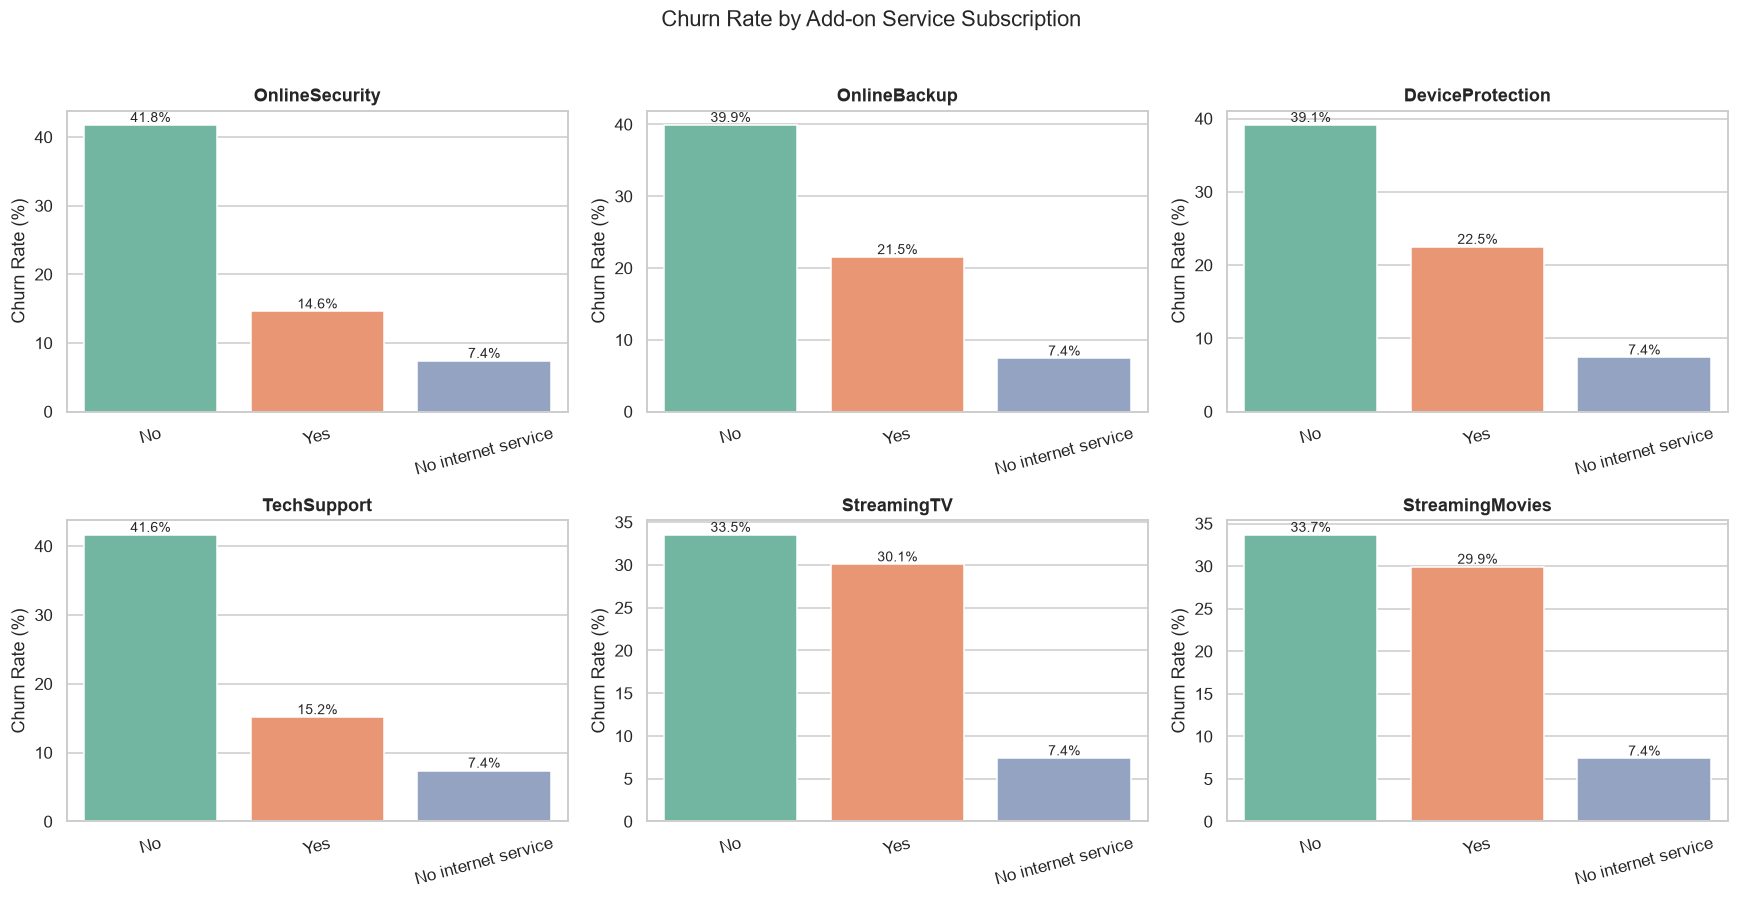

In [12]:
addon_services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, addon_services):
    rate = (df.groupby(col)["Churn_Flag"].mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette="Set2")
    ax.set_title(col)
    ax.set_ylabel("Churn Rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=9)

plt.suptitle("Churn Rate by Add-on Service Subscription", y=1.02)
plt.tight_layout()
plt.show()

**Insight:** A very consistent pattern across **all six add-on services**: customers **without** the service churn roughly **2.5–3x more** than customers **with** it (e.g. `OnlineSecurity`: 41.8% churn if "No" vs 14.6% if "Yes"; `TechSupport`: 41.6% vs 15.2%). Customers with **no internet service** churn the least of all (~7.4%) simply because these add-ons don't apply to them.

This suggests customers who invest in more support/protection add-ons are more engaged and see more value in the service — add-on adoption looks like a strong candidate lever for retention efforts (e.g. bundling security/tech-support into onboarding).

## 7. Churn vs. Numeric Features (Tenure & Charges)

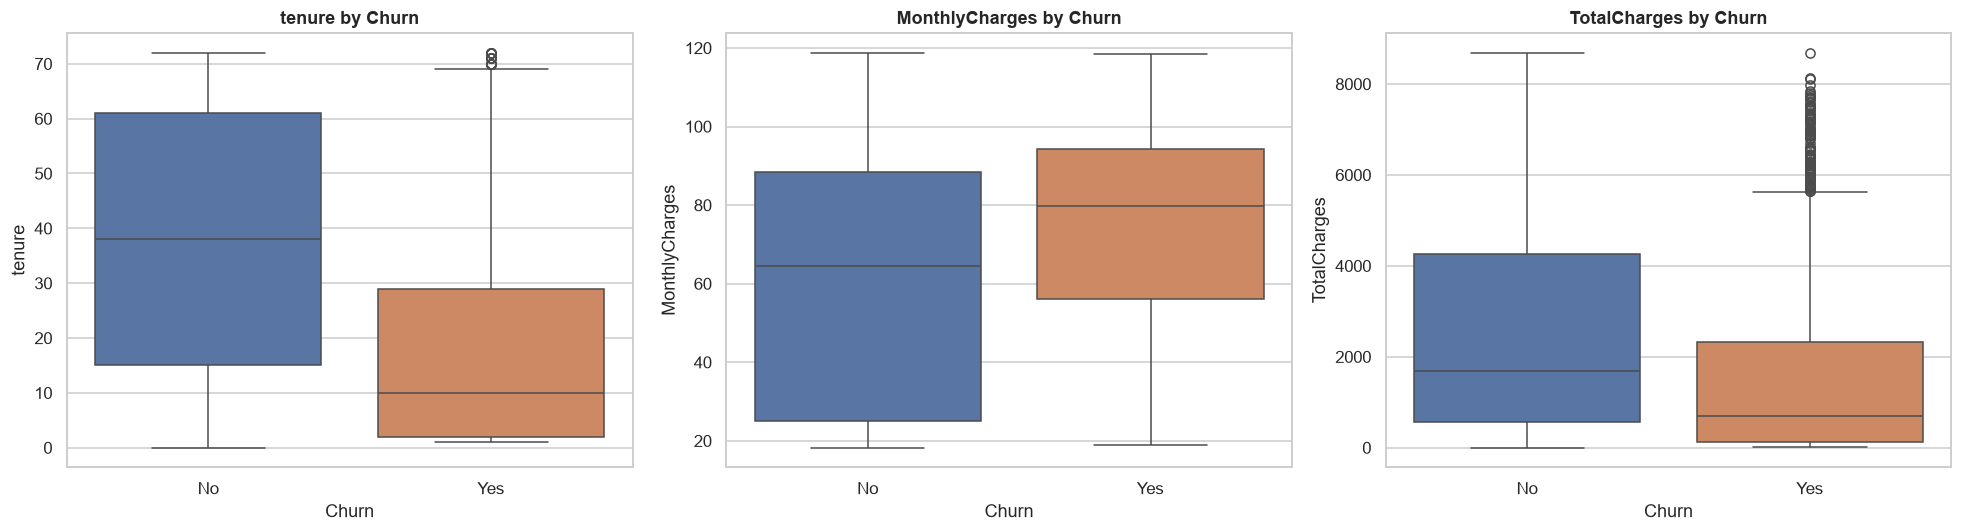

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.6,61.3,2549.9
Yes,18.0,74.4,1531.8


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(data=df, x="Churn", y=col, order=["No", "Yes"], palette=CHURN_COLORS, ax=ax)
    ax.set_title(f"{col} by Churn")

plt.tight_layout()
plt.show()

df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(1)

**Insight:**
- **Tenure** is a strong signal: churners have an average tenure of **~18 months** vs **~37.6 months** for retained customers. Churn is concentrated early in the customer lifecycle.
- **MonthlyCharges** are higher for churners (**$74.4** avg) than non-churners (**$61.3** avg) — consistent with the fiber/electronic-check findings above; higher bills correlate with higher churn.
- **TotalCharges** are *lower* for churners (**$1,532** avg vs **$2,550**) — this is mostly a mechanical effect of short tenure (less time to accumulate charges), not necessarily an independent driver.

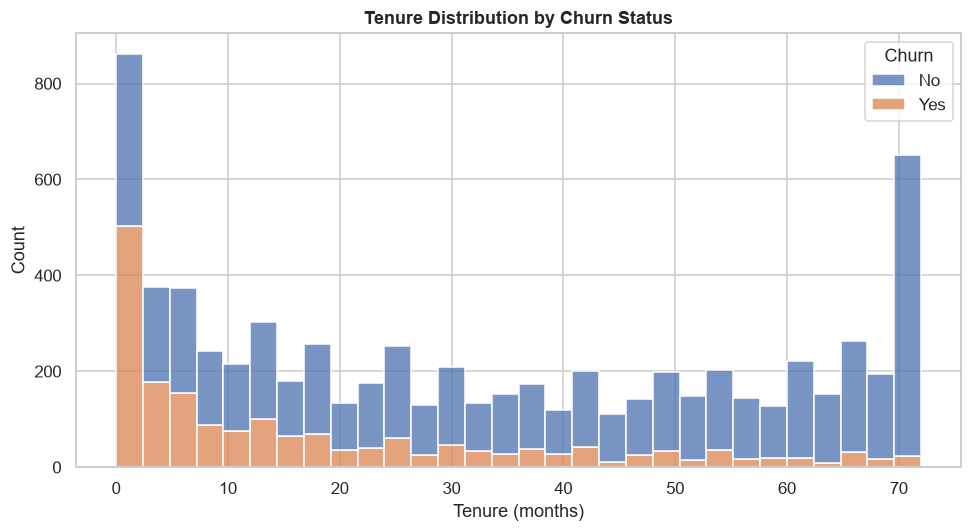

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, palette=CHURN_COLORS, ax=ax)
ax.set_title("Tenure Distribution by Churn Status")
ax.set_xlabel("Tenure (months)")
plt.tight_layout()
plt.show()

**Insight:** Churn is heavily front-loaded — the largest single spike of churners is in the **first 1-5 months** of tenure. Churn risk drops off steadily the longer a customer stays, reinforcing that the first few months are the critical retention window.

## 8. Correlation View

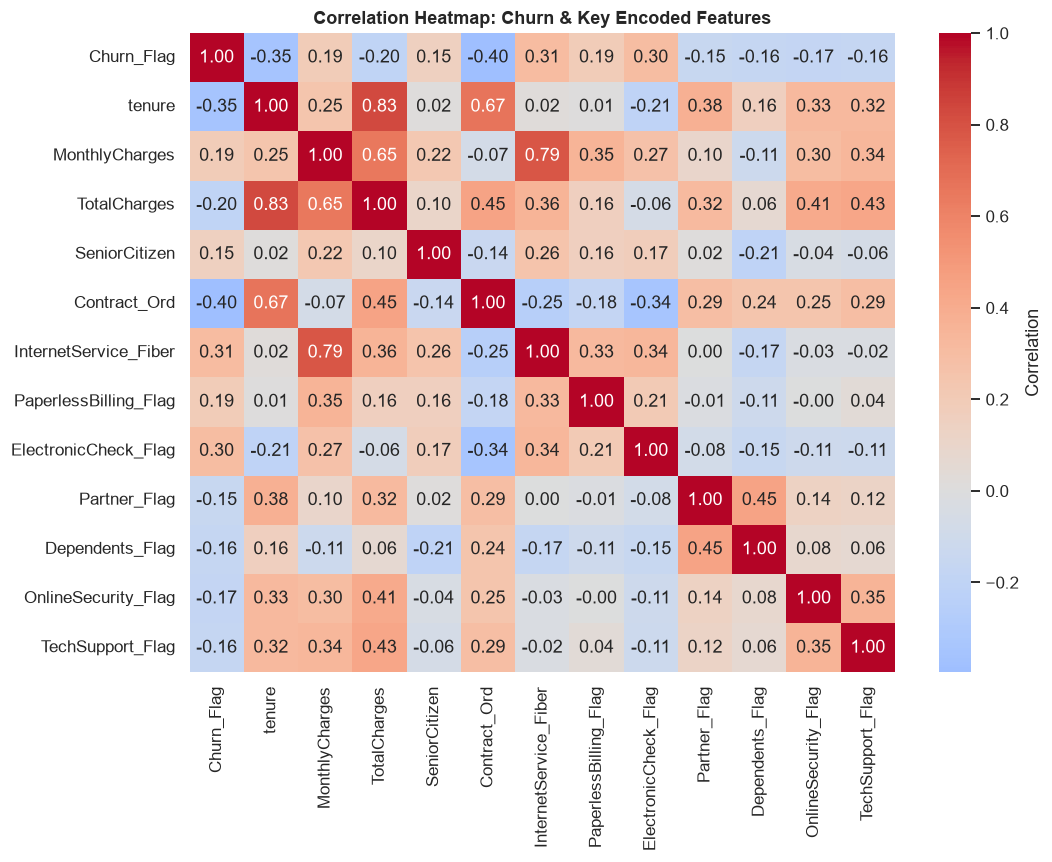

Contract_Ord            -0.396713
tenure                  -0.352229
InternetService_Fiber    0.308020
ElectronicCheck_Flag     0.301919
TotalCharges            -0.198324
MonthlyCharges           0.193356
PaperlessBilling_Flag    0.191825
OnlineSecurity_Flag     -0.171226
TechSupport_Flag        -0.164674
Dependents_Flag         -0.164221
SeniorCitizen            0.150889
Partner_Flag            -0.150448
Name: Churn_Flag, dtype: float64

In [15]:
# Encode key categorical drivers numerically for a correlation heatmap
corr_df = df.copy()
corr_df["Contract_Ord"] = corr_df["Contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})
corr_df["InternetService_Fiber"] = (corr_df["InternetService"] == "Fiber optic").astype(int)
corr_df["PaperlessBilling_Flag"] = (corr_df["PaperlessBilling"] == "Yes").astype(int)
corr_df["ElectronicCheck_Flag"] = (corr_df["PaymentMethod"] == "Electronic check").astype(int)
corr_df["Partner_Flag"] = (corr_df["Partner"] == "Yes").astype(int)
corr_df["Dependents_Flag"] = (corr_df["Dependents"] == "Yes").astype(int)
corr_df["OnlineSecurity_Flag"] = (corr_df["OnlineSecurity"] == "Yes").astype(int)
corr_df["TechSupport_Flag"] = (corr_df["TechSupport"] == "Yes").astype(int)

corr_cols = ["Churn_Flag", "tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen",
             "Contract_Ord", "InternetService_Fiber", "PaperlessBilling_Flag",
             "ElectronicCheck_Flag", "Partner_Flag", "Dependents_Flag",
             "OnlineSecurity_Flag", "TechSupport_Flag"]

corr_matrix = corr_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "Correlation"})
ax.set_title("Correlation Heatmap: Churn & Key Encoded Features")
plt.tight_layout()
plt.show()

corr_matrix["Churn_Flag"].drop("Churn_Flag").sort_values(key=abs, ascending=False)

**Insight:** Ranking features by their absolute correlation with `Churn_Flag` confirms the patterns found visually:
- **`Contract_Ord`** (longer contract) has the strongest **negative** correlation with churn — longer commitment = much lower churn.
- **`tenure`** is also strongly negatively correlated — longevity protects against churn.
- **`OnlineSecurity_Flag` / `TechSupport_Flag`** are negatively correlated — having these add-ons reduces churn likelihood.
- **`InternetService_Fiber`**, **`ElectronicCheck_Flag`**, **`MonthlyCharges`**, and **`PaperlessBilling_Flag`** are all positively correlated with churn.
- **`SeniorCitizen`**, **`Partner_Flag`**, and **`Dependents_Flag`** show weaker but still meaningful correlations, consistent with Section 4.

No single feature dominates completely, but `Contract` and `tenure` clearly stand out as the two most powerful univariate signals in this dataset.

## 9. Summary Dashboard

A single combined view of the top churn drivers, for a one-glance overview.

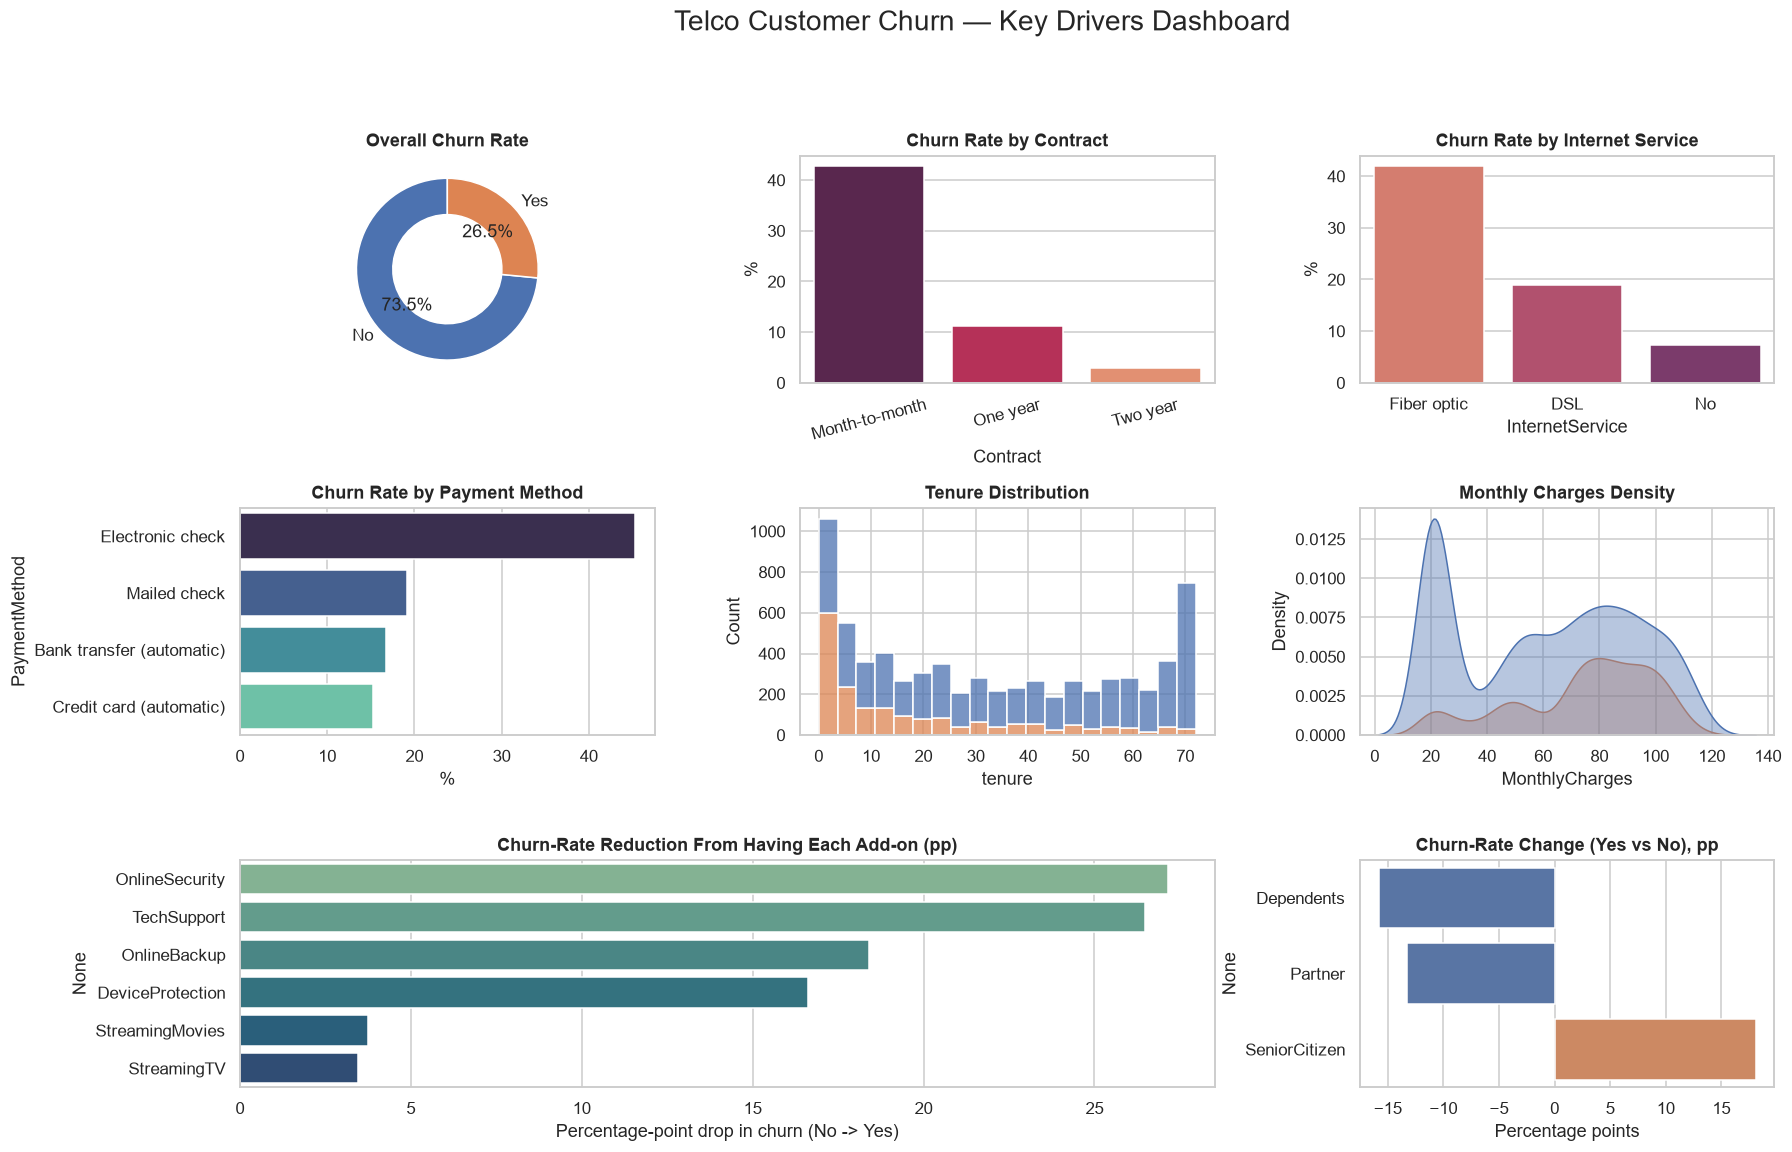

In [16]:
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35)

# 1. Overall churn rate (donut)
ax1 = fig.add_subplot(gs[0, 0])
vals = df["Churn"].value_counts()
ax1.pie(vals, labels=vals.index, autopct="%1.1f%%", colors=[CHURN_COLORS[i] for i in vals.index],
        wedgeprops={"width": 0.4, "edgecolor": "white"}, startangle=90)
ax1.set_title("Overall Churn Rate", fontsize=12)

# 2. Contract
ax2 = fig.add_subplot(gs[0, 1])
order = ["Month-to-month", "One year", "Two year"]
rate = (df.groupby("Contract")["Churn_Flag"].mean() * 100).reindex(order)
sns.barplot(x=rate.index, y=rate.values, ax=ax2, palette="rocket")
ax2.set_title("Churn Rate by Contract", fontsize=12)
ax2.set_ylabel("%")
ax2.tick_params(axis="x", rotation=15)

# 3. Internet Service
ax3 = fig.add_subplot(gs[0, 2])
rate = (df.groupby("InternetService")["Churn_Flag"].mean() * 100).sort_values(ascending=False)
sns.barplot(x=rate.index, y=rate.values, ax=ax3, palette="flare")
ax3.set_title("Churn Rate by Internet Service", fontsize=12)
ax3.set_ylabel("%")

# 4. Payment method
ax4 = fig.add_subplot(gs[1, 0])
rate = (df.groupby("PaymentMethod")["Churn_Flag"].mean() * 100).sort_values(ascending=False)
sns.barplot(x=rate.values, y=rate.index, ax=ax4, palette="mako")
ax4.set_title("Churn Rate by Payment Method", fontsize=12)
ax4.set_xlabel("%")

# 5. Tenure distribution
ax5 = fig.add_subplot(gs[1, 1])
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=20, palette=CHURN_COLORS,
             ax=ax5, legend=False)
ax5.set_title("Tenure Distribution", fontsize=12)

# 6. Monthly charges by churn
ax6 = fig.add_subplot(gs[1, 2])
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", palette=CHURN_COLORS, fill=True, alpha=0.4, ax=ax6, legend=False)
ax6.set_title("Monthly Charges Density", fontsize=12)

# 7. Add-on services (avg churn reduction)
ax7 = fig.add_subplot(gs[2, 0:2])
addon_gap = {}
for col in addon_services:
    r = df.groupby(col)["Churn_Flag"].mean() * 100
    if "Yes" in r.index and "No" in r.index:
        addon_gap[col] = r["No"] - r["Yes"]
addon_gap = pd.Series(addon_gap).sort_values(ascending=False)
sns.barplot(x=addon_gap.values, y=addon_gap.index, ax=ax7, palette="crest")
ax7.set_title("Churn-Rate Reduction From Having Each Add-on (pp)", fontsize=12)
ax7.set_xlabel("Percentage-point drop in churn (No -> Yes)")

# 8. Demographics summary
ax8 = fig.add_subplot(gs[2, 2])
demo_gap = {}
for col, labels in [("SeniorCitizen_Label", ("No", "Yes")), ("Partner", ("No", "Yes")), ("Dependents", ("No", "Yes"))]:
    r = df.groupby(col)["Churn_Flag"].mean() * 100
    demo_gap[col.replace("_Label", "")] = r[labels[1]] - r[labels[0]]
demo_gap = pd.Series(demo_gap).sort_values()
colors_demo = ["#4C72B0" if v < 0 else "#DD8452" for v in demo_gap.values]
sns.barplot(x=demo_gap.values, y=demo_gap.index, ax=ax8, palette=colors_demo)
ax8.set_title("Churn-Rate Change (Yes vs No), pp", fontsize=12)
ax8.set_xlabel("Percentage points")

fig.suptitle("Telco Customer Churn — Key Drivers Dashboard", fontsize=18, y=1.0)
plt.show()

## 10. Key Insights & Takeaways

Ranked by strength of association with churn found in this EDA:

1. **Contract type is the #1 driver.** Month-to-month customers churn at 42.7% vs 2.8% for two-year contracts. Pushing customers toward longer commitments (via incentives/discounts) is the single highest-leverage retention action.
2. **Tenure matters — churn is front-loaded.** New customers (first ~5 months) are at the highest risk. Onboarding and early-life engagement programs likely have outsized impact.
3. **Lack of support/security add-ons predicts churn.** Customers without `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection`, `StreamingTV`, or `StreamingMovies` churn 2.5–3x more than those with them — bundling or promoting these could reduce churn.
4. **Fiber optic internet and higher monthly bills correlate with churn.** This is likely tied to price sensitivity or service-quality perception on the premium tier, not the technology itself.
5. **Electronic check payers and paperless-billing customers churn more**, likely reflecting a less "locked-in" segment (no autopay) rather than the payment method causing churn directly.
6. **Demographics play a secondary role.** Senior citizens, and customers without a partner or dependents, churn more — consistent with a "single household, less anchored" customer profile. Gender has no meaningful effect.

**Caveat:** all findings above are *associations* from descriptive EDA, not causal claims — a follow-up predictive model (e.g. logistic regression or tree-based classifier) with proper train/test validation and feature importance analysis would be needed to confirm which factors are independently predictive once interactions are controlled for.